# 03 — Modeling

## Purpose

Build **three forecasting models** of increasing complexity and evaluate them on the 56-day holdout window. The data is aggregated at the **category × store level** (30 groups), predicting total daily sales for each category at each store.

### The Models
1. **Seasonal Naive** — predict today = sales 7 days ago (zero training)
2. **Ridge Regression** — linear model with L2 penalty (fast, interpretable)
3. **XGBoost** — gradient-boosted trees (captures nonlinearity and feature interactions)

### Evaluation
- **RMSE and MAE** on the full holdout set — both symmetric metrics
- Per-category breakdown (FOODS vs. HOUSEHOLD vs. HOBBIES)
- Comparison table ranking all three models

**Important caveat**: RMSE assumes overpredicting by 100 units is equally costly as underpredicting by 100 units. In real inventory decisions, understocking (lost sales, lost customers) typically costs more than overstocking (holding cost). Notebook 04 introduces **asymmetric cost evaluation** to address this gap.

### Input / Output
- **Input**: `data/output/features.csv` (training), `data/output/features_holdout.csv` (evaluation) — aggregated to category × store level in notebook 02
- **Output**: `data/output/predictions.csv`, `data/output/model_comparison.csv`

In [1]:
import os

BASE_DIR = '..'
OUTPUT_DIR = f'{BASE_DIR}/data/output'
FIG_DIR = f'{BASE_DIR}/figures'
MODEL_DIR = f'{BASE_DIR}/models'

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Project dir: {BASE_DIR}')

Project dir: ..


In [2]:
import pandas as pd
import numpy as np
import gc
import time
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

train = pd.read_csv(f'{OUTPUT_DIR}/features.csv', parse_dates=['date'])
holdout = pd.read_csv(f'{OUTPUT_DIR}/features_holdout.csv', parse_dates=['date'])

print(f'train: {train.shape}')
print(f'holdout: {holdout.shape}')
print(f'category-store pairs: {train["id"].nunique()}')

train: (54870, 35)
holdout: (1680, 35)
category-store pairs: 30


## Step 2: Feature Preparation

Select all numeric features, excluding metadata columns (IDs, join keys), text columns, and the target.

In [3]:
META_COLS = ['id', 'cat_id', 'store_id', 'state_id']
DROP_COLS = META_COLS + ['date', 'event_type', 'sales']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]

X_train = train[FEATURE_COLS].copy()
y_train = train['sales'].values.astype('float32')
X_holdout = holdout[FEATURE_COLS].copy()
y_holdout = holdout['sales'].values.astype('float32')

print(f'Features: {len(FEATURE_COLS)}')
print(f'X_train: {X_train.shape}')
print(f'X_holdout: {X_holdout.shape}')
print(f'\nFeature list:')
for i, col in enumerate(FEATURE_COLS):
    print(f'  {i+1:2d}. {col}')

Features: 28
X_train: (54870, 28)
X_holdout: (1680, 28)

Feature list:
   1. sales_lag_7
   2. sales_lag_14
   3. sales_lag_28
   4. rolling_mean_7
   5. rolling_mean_28
   6. rolling_std_7
   7. rolling_max_7
   8. sell_price
   9. price_change_pct
  10. price_lag_7
  11. price_lag_28
  12. snap_issuance_proximity
  13. day_of_week
  14. month
  15. week_of_year
  16. is_weekend
  17. days_until_event
  18. event_magnitude
  19. temp_high_f
  20. precipitation_in
  21. is_rainy
  22. unemployment_state
  23. cpi
  24. is_school_session
  25. is_summer_break
  26. back_to_school_proximity
  27. back_to_school_recency
  28. price_relative


---

## Step 3: Model 1 — Seasonal Naive

The simplest baseline: predict today's sales = what they were 7 days ago. The `sales_lag_7` feature already exists in holdout (recomputed on aggregated sales). No training needed.

### Mathematical Formulation

$$\hat{y}_t = y_{t-7}$$

where $\hat{y}_t$ is the predicted sales on day $t$, and $y_{t-7}$ is actual sales exactly one week earlier. No parameters to estimate, no assumptions beyond weekly seasonality.

### Why Seasonal Naive?

Seasonal Naive exploits the strongest pattern in retail data: **weekly seasonality**. A category-store group that sells 500 units of FOODS on Monday will likely sell around 500 again next Monday. At the aggregated level, this pattern is stronger because individual item noise cancels out.

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

t0 = time.time()
holdout['pred_naive'] = holdout['sales_lag_7'].fillna(0).clip(lower=0).astype('float32')
naive_time = time.time() - t0

rmse = np.sqrt(mean_squared_error(y_holdout, holdout['pred_naive']))
mae = mean_absolute_error(y_holdout, holdout['pred_naive'])
print(f'Seasonal Naive: RMSE={rmse:.3f}, MAE={mae:.3f} ({naive_time:.2f}s)')

Seasonal Naive: RMSE=8.414, MAE=5.371 (0.00s)


### Interpretation

The Seasonal Naive sets our **baseline floor**. Any model that cannot beat it is not learning anything useful from the features — it would be better to just copy last week's sales. At the aggregated level, this baseline should be stronger than at item level because weekly patterns are more stable.

---

## Step 4: Model 2 — Ridge Regression

A regularized linear model. Ridge minimizes squared error plus an L2 penalty on coefficient magnitudes:

$$\min_{\boldsymbol{\beta}} \left\{ \sum_{i=1}^{n} (y_i - \mathbf{x}_i^T \boldsymbol{\beta})^2 + \alpha \|\boldsymbol{\beta}\|_2^2 \right\}$$

where $\alpha = 1.0$ controls regularization strength.

Ridge needs two preprocessing steps:
1. **Impute NaN** — some features have missing values (filled with median)
2. **Scale features** — the L2 penalty is sensitive to feature magnitude, so all features must be on the same scale

We use an sklearn `Pipeline` so preprocessing is fit on training data only.

In [5]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib

ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0, random_state=SEED))
])

t0 = time.time()
ridge_pipe.fit(X_train, y_train)
ridge_time = time.time() - t0

holdout['pred_ridge'] = ridge_pipe.predict(X_holdout).clip(min=0).astype('float32')
rmse = np.sqrt(mean_squared_error(y_holdout, holdout['pred_ridge']))
mae = mean_absolute_error(y_holdout, holdout['pred_ridge'])
print(f'Ridge: RMSE={rmse:.3f}, MAE={mae:.3f} ({ridge_time:.2f}s)')

joblib.dump(ridge_pipe, f'{MODEL_DIR}/ridge_pipeline.joblib')
print('Saved: models/ridge_pipeline.joblib')

Ridge: RMSE=6.375, MAE=4.107 (0.10s)
Saved: models/ridge_pipeline.joblib


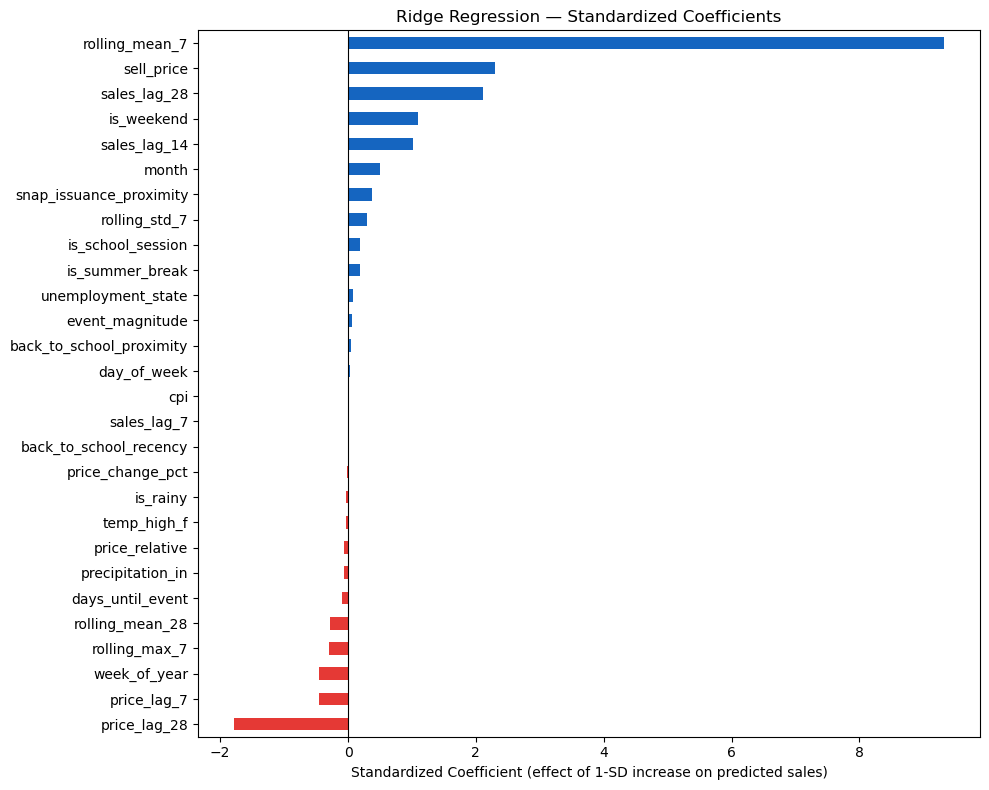

In [6]:
import matplotlib.pyplot as plt

# Extract coefficients from the pipeline (after scaling)
coefs = pd.Series(
    ridge_pipe.named_steps['ridge'].coef_,
    index=FEATURE_COLS
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E53935' if v < 0 else '#1565C0' for v in coefs]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient (effect of 1-SD increase on predicted sales)')
ax.set_title('Ridge Regression — Standardized Coefficients')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ridge_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

**`rolling_mean_7` dominates** with a coefficient of ~9.5 — by far the strongest predictor. A 1-SD increase in the 7-day rolling average raises predicted sales by ~9.5 units. Recent sales history is the single most powerful demand signal at the aggregated level.

**`sell_price` is positive (~2.3)** — counterintuitive at first, since higher prices should suppress demand. However, at the category-store level, higher-priced groups (e.g., FOODS at a large store) tend to have higher sales volume overall. The coefficient captures a **level effect** — expensive groups sell more units — rather than a price elasticity. The actual price sensitivity features (`price_change_pct`, `price_relative`) are near zero, suggesting that *changes* in price have weak linear effects, possibly because the true relationship is nonlinear and Ridge cannot capture it.

**`price_lag_28` is the largest negative coefficient (~-1.8)** — when the price 28 days ago was elevated relative to its standard deviation, today's predicted sales decrease. This may reflect a delayed demand adjustment: if prices were high a month ago, current demand is still recovering.

**`is_weekend` is positive (~1.1)** — weekends drive higher category-store sales, consistent with typical retail foot traffic patterns.

**Most external features cluster near zero** — `cpi`, `temp_high_f`, `is_rainy`, `event_magnitude`, and `back_to_school_proximity` all have negligible linear effects. Two possible explanations: (1) these features genuinely contribute little at the aggregated level, or (2) their effects are nonlinear (e.g., rain matters only above a threshold), which Ridge cannot capture. Comparing these rankings against XGBoost's SHAP values (below) can distinguish between the two.

**`rolling_mean_28` and `rolling_max_7` are negative** — this is a sign of **multicollinearity** with `rolling_mean_7`. When highly correlated features enter a linear model together, their coefficients can flip signs. The model effectively says: "anchor to the 7-day mean, then *subtract* if the 28-day mean or 7-day max diverge from it." The individual signs are not meaningful in isolation — the group of rolling features operates as a unit.

---

## Step 5: Model 3 — XGBoost

XGBoost builds an ensemble of $K$ decision trees additively:

$$\hat{y}_i = \sum_{k=1}^{K} f_k(\mathbf{x}_i)$$

Each tree $f_k$ is fit to the **residuals** of all previous trees. The objective at step $t$:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l\left(y_i,\; \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)\right) + \Omega(f_t)$$

where $\Omega(f_t) = \gamma T + \frac{1}{2}\lambda \|w\|^2$ penalizes tree complexity ($T$ = leaves, $w$ = leaf weights).

Key advantages:
- **Handles NaN natively** — learns optimal split direction for missing values
- **Captures nonlinear relationships and feature interactions**
- **Robust to feature scale** — no preprocessing needed

**Early stopping without leaking holdout**: Using the holdout as the early-stopping `eval_set` would let XGBoost peek at unseen data to pick `best_iteration` — a mild form of holdout tuning. Instead, we carve a 56-day temporal validation slice from the *end of the training window* (the last 56 train dates per category-store), use that for early stopping with `early_stopping_rounds=50`, then **refit the final model on the full train set** with `n_estimators` fixed at the discovered `best_iteration`. The holdout is touched exactly once, for final evaluation.

In [7]:
import xgboost as xgb

# Carve a 56-day temporal validation slice from the END of the training window,
# per category-store. Used only for early stopping — never exposed to holdout.
INNER_VAL_DAYS = 56
inner_cutoff = train['date'].max() - pd.Timedelta(days=INNER_VAL_DAYS - 1)
inner_val_mask = train['date'] >= inner_cutoff

X_train_inner = X_train.loc[~inner_val_mask]
y_train_inner = y_train[~inner_val_mask.values]
X_train_val   = X_train.loc[inner_val_mask]
y_train_val   = y_train[inner_val_mask.values]
print(f'Inner train: {X_train_inner.shape}   inner val: {X_train_val.shape}')

# Phase 1: fit with early stopping on the inner validation slice
xgb_search = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    random_state=SEED,
    verbosity=0,
    early_stopping_rounds=50,
)
xgb_search.fit(
    X_train_inner, y_train_inner,
    eval_set=[(X_train_val, y_train_val)],
    verbose=100,
)
best_iter = xgb_search.best_iteration + 1   # XGB best_iteration is zero-indexed
print(f'Best iteration (from inner val): {best_iter}')

# Phase 2: refit on the FULL training set with n_estimators fixed at best_iter
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=best_iter,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    random_state=SEED,
    verbosity=0,
)

t0 = time.time()
xgb_model.fit(X_train, y_train, verbose=False)
xgb_time = time.time() - t0

holdout['pred_xgb'] = xgb_model.predict(X_holdout).clip(min=0).astype('float32')
rmse = np.sqrt(mean_squared_error(y_holdout, holdout['pred_xgb']))
mae = mean_absolute_error(y_holdout, holdout['pred_xgb'])
print(f'XGBoost: RMSE={rmse:.3f}, MAE={mae:.3f} ({xgb_time:.2f}s, n_estimators={best_iter})')

xgb_model.save_model(f'{MODEL_DIR}/xgboost_model.json')
print('Saved: models/xgboost_model.json')


Inner train: (53190, 28)   inner val: (1680, 28)
[0]	validation_0-rmse:13.54918


[100]	validation_0-rmse:6.48718


[146]	validation_0-rmse:6.52122


Best iteration (from inner val): 97


XGBoost: RMSE=6.048, MAE=3.904 (0.27s, n_estimators=97)
Saved: models/xgboost_model.json


### Feature Importance

Which features does XGBoost rely on most? Rolling means and lags should dominate, but weather/macro features may rank higher now that item-level noise is removed.

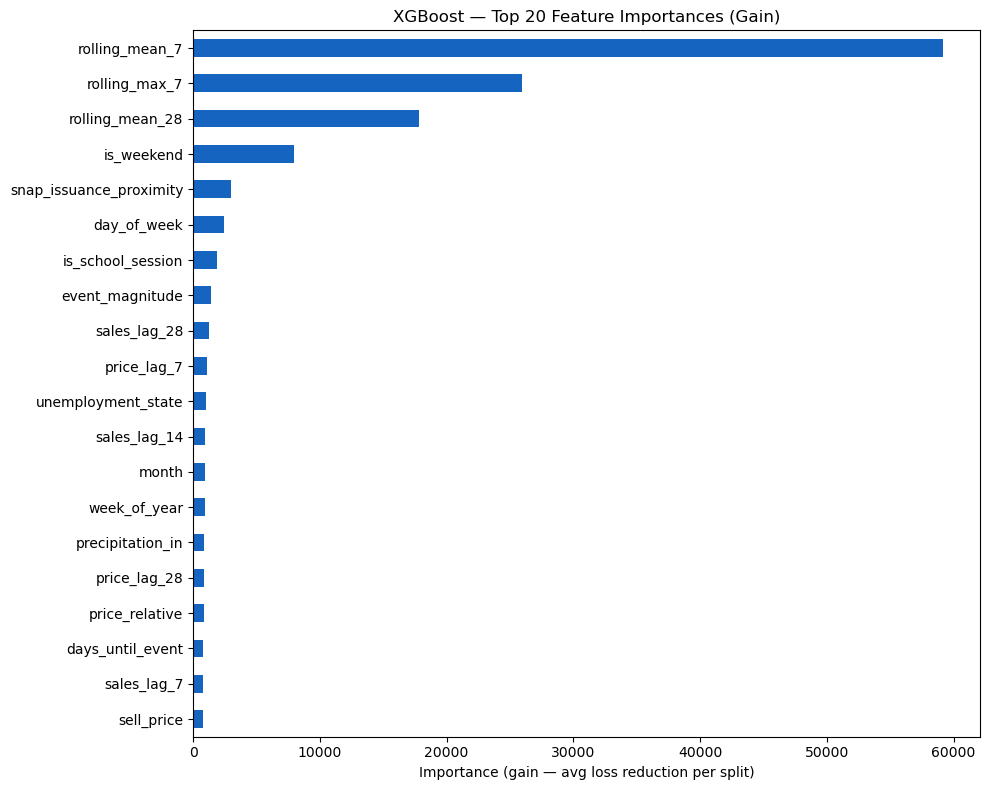

Saved: figures/xgb_feature_importance.png


In [8]:
import matplotlib.pyplot as plt

# Use gain (average loss reduction per split) — more meaningful than weight (split count)
booster_temp = xgb_model.get_booster()
gain_scores = booster_temp.get_score(importance_type='gain')
importances = pd.Series(gain_scores, dtype='float64').reindex(FEATURE_COLS, fill_value=0)

top20 = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.plot(kind='barh', ax=ax, color='#1565C0')
ax.set_xlabel('Importance (gain — avg loss reduction per split)')
ax.set_title('XGBoost — Top 20 Feature Importances (Gain)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/xgb_feature_importance.png')

### Interpretation

At the aggregated level, XGBoost's feature importance may shift compared to the item-level model. Rolling means and lags will still dominate, but weather/macro features may rank higher now that item-level noise is removed.

### Gain vs. Cover — Feature Importance Diagnostic

XGBoost provides three importance measures, each answering a different question:

| Metric | Measures | Interpretation |
|---|---|---|
| **Gain** | Average loss reduction per split | How much a feature *improves* predictions |
| **Cover** | Average number of samples affected per split | How *broadly* a feature influences predictions |
| **Weight** | Number of splits using the feature | How *often* the model relies on a feature structurally |

Plotting **gain against cover** reveals four quadrants:

| Quadrant | Meaning |
|---|---|
| **High gain, high cover** | Strong, broad signal — the model's workhorses |
| **High gain, low cover** | Strong but narrow — powerful for a small subset, potential **overfitting risk** |
| **Low gain, high cover** | Weak but broad — touches many predictions but adds little value per split; possibly **redundant or noisy** |
| **Low gain, low cover** | Weak and narrow — minimal contribution overall |

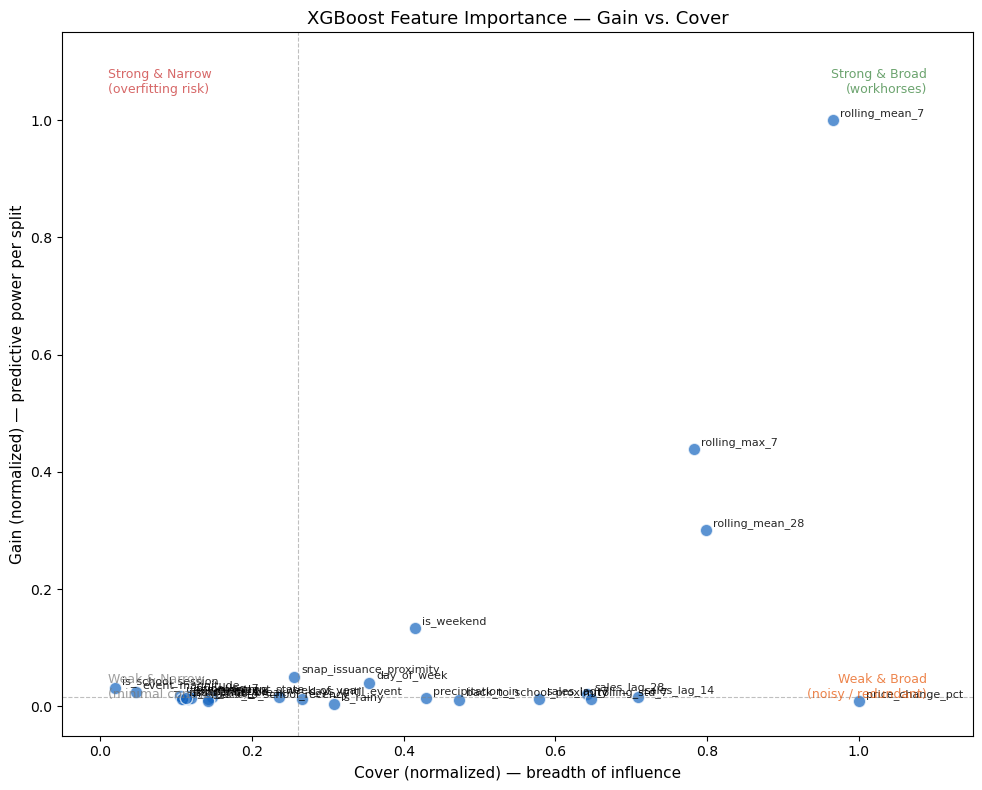

Saved: figures/xgb_gain_vs_cover.png


In [9]:
# Extract gain and cover importance from the booster
booster = xgb_model.get_booster()
gain_dict = booster.get_score(importance_type='gain')
cover_dict = booster.get_score(importance_type='cover')

# Build DataFrame — align on feature names (booster returns actual feature names)
imp_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'gain': [gain_dict.get(f, 0) for f in FEATURE_COLS],
    'cover': [cover_dict.get(f, 0) for f in FEATURE_COLS],
})

# Normalize to [0, 1] for comparable axes
imp_df['gain_norm'] = imp_df['gain'] / imp_df['gain'].max()
imp_df['cover_norm'] = imp_df['cover'] / imp_df['cover'].max()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(imp_df['cover_norm'], imp_df['gain_norm'], s=80, color='#1565C0', alpha=0.7, edgecolors='white')

# Label every point
for _, row in imp_df.iterrows():
    ax.annotate(row['feature'], (row['cover_norm'], row['gain_norm']),
                fontsize=8, alpha=0.85, ha='left',
                xytext=(5, 3), textcoords='offset points')

# Quadrant lines at median
med_gain = imp_df['gain_norm'].median()
med_cover = imp_df['cover_norm'].median()
ax.axhline(med_gain, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(med_cover, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Quadrant labels
ax.text(0.95, 0.95, 'Strong & Broad\n(workhorses)', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='#2E7D32', alpha=0.7)
ax.text(0.05, 0.95, 'Strong & Narrow\n(overfitting risk)', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='#C62828', alpha=0.7)
ax.text(0.95, 0.05, 'Weak & Broad\n(noisy / redundant)', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9, color='#E65100', alpha=0.7)
ax.text(0.05, 0.05, 'Weak & Narrow\n(minimal contribution)', transform=ax.transAxes,
        ha='left', va='bottom', fontsize=9, color='#757575', alpha=0.7)

ax.set_xlabel('Cover (normalized) — breadth of influence', fontsize=11)
ax.set_ylabel('Gain (normalized) — predictive power per split', fontsize=11)
ax.set_title('XGBoost Feature Importance — Gain vs. Cover', fontsize=13)
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/xgb_gain_vs_cover.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/xgb_gain_vs_cover.png')

### Interpretation

**How to read the quadrants:**

- **Top-right (Strong & Broad):** These features are the model's workhorses — they improve predictions significantly *and* affect a large share of samples. Lag and rolling features typically land here, confirming they carry the strongest demand signal.
- **Top-left (Strong & Narrow):** High predictive power but only for a small subset of the data. Worth investigating — the model may be memorizing a niche pattern (e.g., a rare event type or a specific price regime). If a feature lands here, ask: *does this generalize, or is it overfitting to a few hundred rows?*
- **Bottom-right (Weak & Broad):** The feature is involved in many predictions but adds minimal value per split. Candidates for removal or re-engineering — they add complexity without proportional accuracy gain.
- **Bottom-left (Weak & Narrow):** Minimal contribution overall. These features could likely be dropped without degrading performance.

### SHAP Values — Feature Direction and Magnitude

Gain and cover tell us *how much* a feature matters, but not *in which direction*. SHAP (SHapley Additive exPlanations) decomposes every individual prediction into per-feature contributions:

$$\hat{y}_i = \phi_0 + \sum_{j=1}^{M} \phi_j^{(i)}$$

where $\phi_0$ is the baseline (mean prediction) and $\phi_j^{(i)}$ is feature $j$'s contribution to prediction $i$. Each dot in the beeswarm plot is one holdout observation — its x-position shows how much that feature pushed the prediction up (right) or down (left), and its color shows the feature's actual value (red = high, blue = low).

This answers questions gain cannot: *does a higher `sell_price` increase or decrease predicted demand? Does proximity to a SNAP issuance date push sales up?*

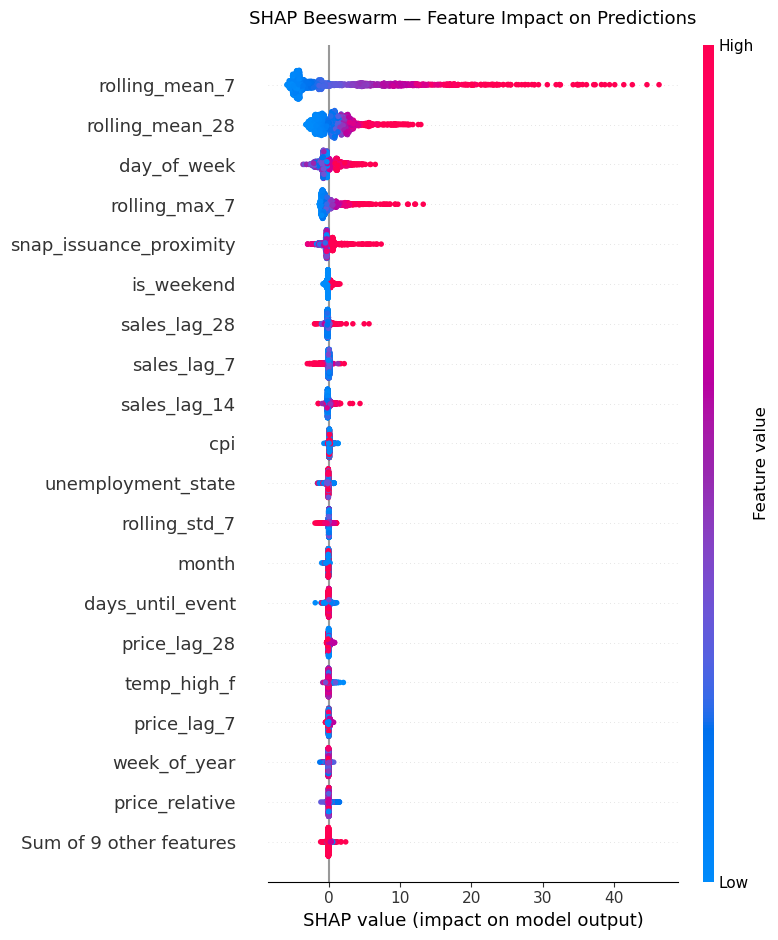

Saved: figures/shap_beeswarm.png


In [10]:
import shap

# Compute SHAP values on holdout set (TreeExplainer is exact for tree models)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_holdout)

# --- Beeswarm plot: direction + magnitude for every feature ---
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Predictions', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/shap_beeswarm.png')

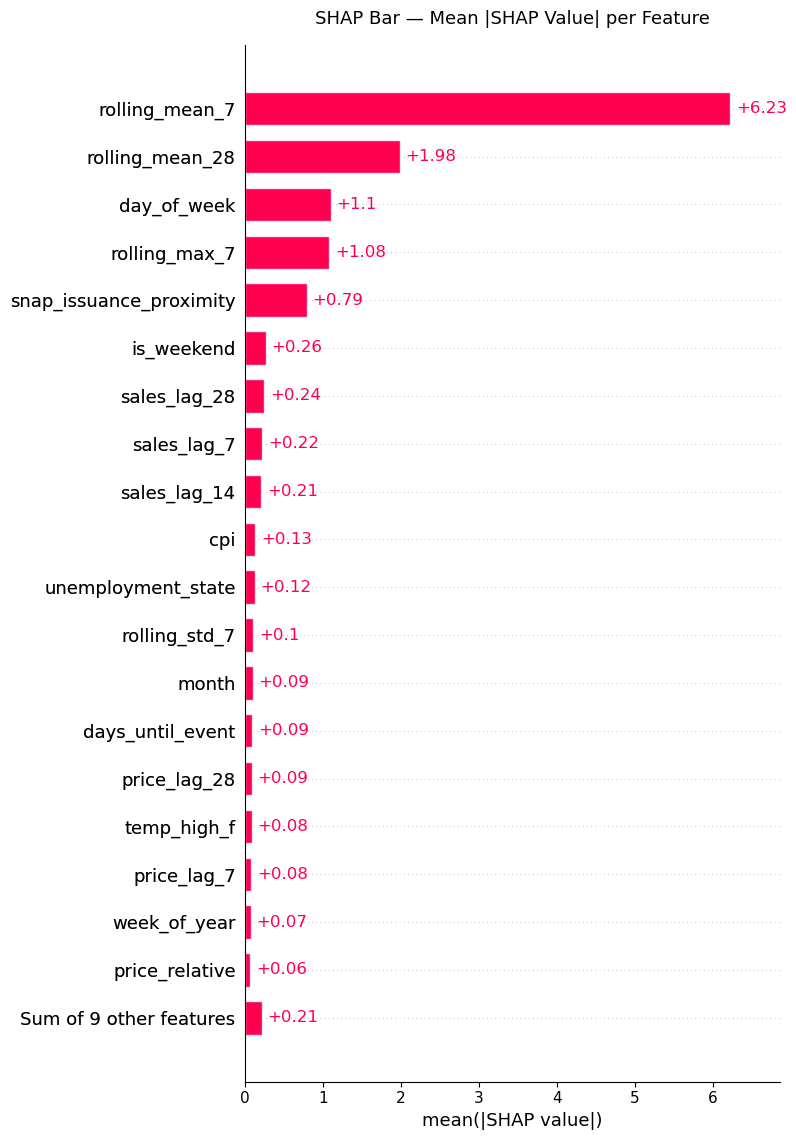

Saved: figures/shap_bar.png


In [11]:
# --- SHAP bar plot: mean absolute SHAP value per feature (global importance) ---
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('SHAP Bar — Mean |SHAP Value| per Feature', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/shap_bar.png')

### Interpretation

**`rolling_mean_7` dominates both SHAP rankings** with a mean |SHAP value| of 5.91 — more than 3× the next feature. The beeswarm confirms the expected direction: high rolling mean (red dots) pushes predictions strongly rightward (higher sales), while low rolling mean (blue dots) pushes leftward. This is consistent with Ridge, where `rolling_mean_7` had the largest coefficient (~9.5).

**`rolling_max_7` and `rolling_mean_28` rank 2nd and 3rd** (1.75 and 1.71 mean |SHAP|). Unlike Ridge — where these features had *negative* coefficients due to multicollinearity — XGBoost uses them with the correct positive direction (red = high value = higher predicted sales). This confirms that Ridge's negative signs were an artifact of collinearity, not a genuine inverse relationship. XGBoost, which handles correlated features through tree splits rather than linear coefficients, avoids this distortion.

**`day_of_week` ranks 4th** (1.22 mean |SHAP|) with clear bidirectional spread — certain days of the week push predictions up, others push them down. This captures weekly seasonality that the Seasonal Naive baseline also exploits, but XGBoost learns the pattern conditionally (e.g., weekday effects may differ by category).

**`snap_issuance_proximity` ranks 5th** (0.78 mean |SHAP|) — a notable result. In Ridge, this feature had a small positive coefficient (~0.4). SHAP reveals that the effect is concentrated: high proximity values (red, close to SNAP issuance) push predictions upward, while low proximity values have near-zero effect. This suggests a **threshold effect** rather than a linear relationship — SNAP benefits only matter when issuance is imminent.

**`sell_price` has near-zero SHAP impact** (0.05 mean |SHAP|) — a striking contrast with Ridge, where it was the 2nd-largest coefficient (~2.3). Ridge's positive `sell_price` coefficient was acting as a **proxy for category-store identity** (high-price groups = high-volume groups). XGBoost captures this level difference through other features (rolling means already encode the group's typical sales volume), making `sell_price` redundant. This confirms that Ridge's `sell_price` coefficient reflected confounding, not a genuine price-demand relationship.

**External features (`unemployment_state`, `cpi`, `temp_high_f`) remain weak** in both models — SHAP values of 0.05–0.11. At the category-store aggregation level, these macro signals are too diffuse to meaningfully shift demand predictions. This does not mean they are irrelevant to demand; their effects may emerge at the item level where individual product sensitivity to weather or economic conditions can be isolated.

### Partial Dependence Plots — Shape of Feature Effects

SHAP shows *that* a feature matters and in which direction. Partial Dependence Plots (PDPs) show **the functional form** of that relationship — is it linear, threshold-based, or nonlinear?

A PDP answers: *holding all other features constant, how does the predicted sales change as this one feature varies across its range?*

We plot four features chosen for their business relevance:
- **`sell_price`** — does demand fall linearly with price, or is there a threshold where it drops sharply?
- **`snap_issuance_proximity`** — how far does the SNAP effect reach?
- **`event_magnitude`** — do larger events proportionally boost sales, or is there a saturation point?
- **`rolling_mean_7`** — how tightly does the model anchor to recent sales history?

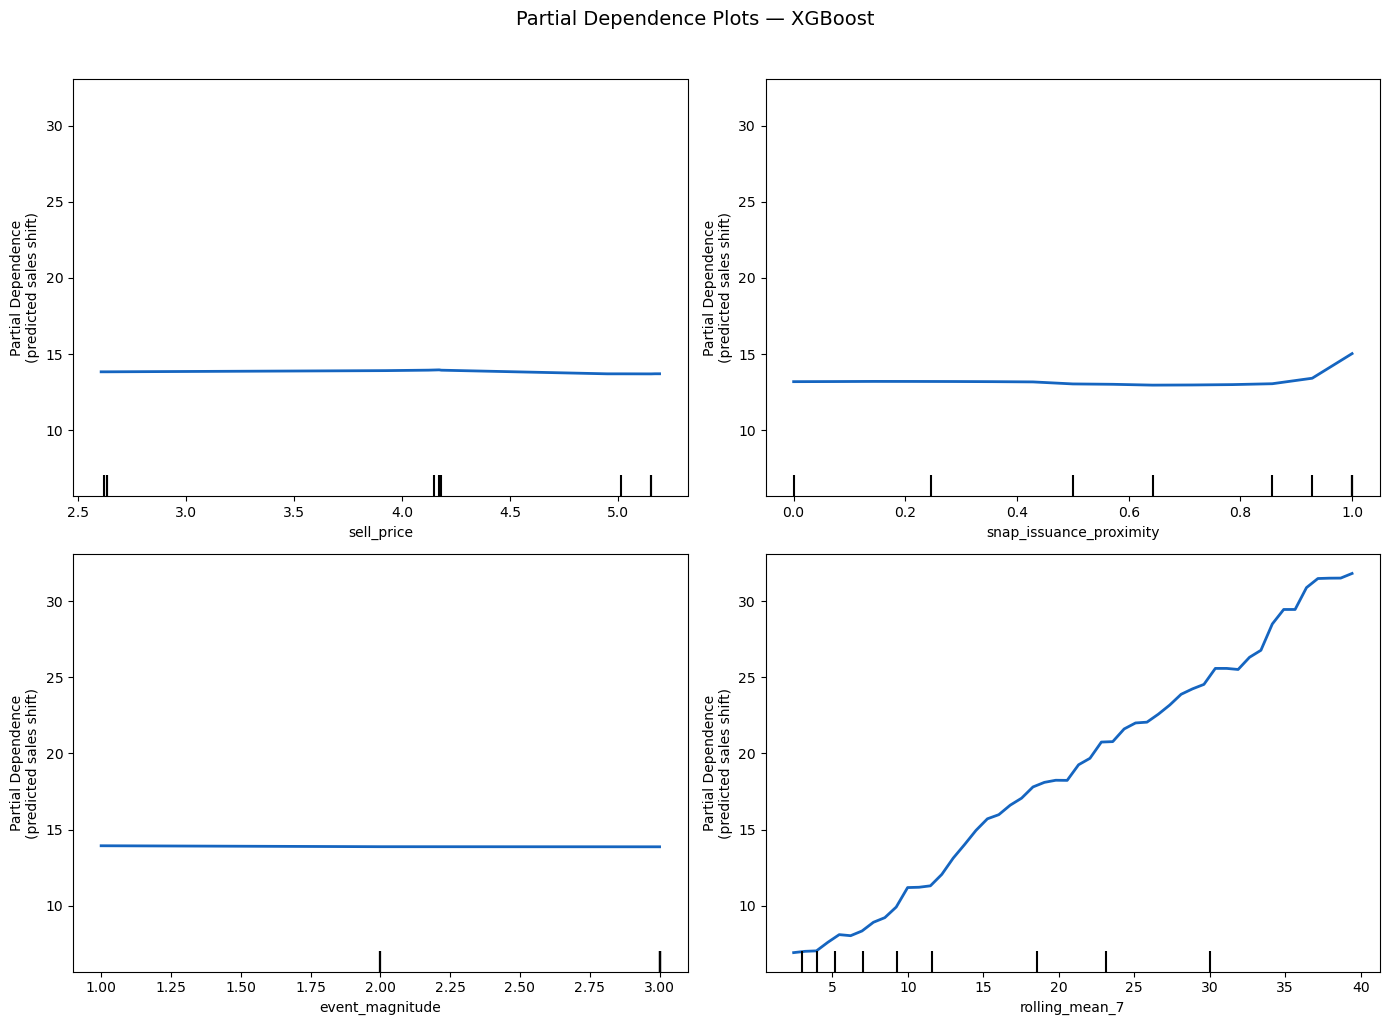

Saved: figures/xgb_partial_dependence.png


In [12]:
from sklearn.inspection import PartialDependenceDisplay

pdp_features = ['sell_price', 'snap_issuance_proximity', 'event_magnitude', 'rolling_mean_7']
pdp_indices = [FEATURE_COLS.index(f) for f in pdp_features]

# Fill NaN for PDP computation (XGBoost handles NaN, but sklearn PDP requires finite values)
X_holdout_filled = X_holdout.fillna(X_train.median())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
display = PartialDependenceDisplay.from_estimator(
    xgb_model, X_holdout_filled, pdp_indices,
    feature_names=FEATURE_COLS,
    kind='average',       # average effect (not individual)
    ax=axes.ravel(),
    grid_resolution=50,
    line_kw={'color': '#1565C0', 'linewidth': 2},
)

for ax in axes.ravel():
    ax.set_ylabel('Partial Dependence\n(predicted sales shift)')

plt.suptitle('Partial Dependence Plots — XGBoost', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/xgb_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/xgb_partial_dependence.png')

### Interpretation

**`sell_price` — flat across the entire range** (~14 predicted sales regardless of price level). XGBoost finds no marginal price effect at the category-store level. This reinforces the SHAP finding: Ridge's large positive `sell_price` coefficient was a confound (proxy for group identity), not a price elasticity. To detect genuine price sensitivity, item-level models would be needed — where a price drop on a specific SKU can be isolated from the group's baseline volume.

**`snap_issuance_proximity` — flat until ~0.9, then a sharp uptick** to ~15 at proximity = 1.0. This is a clear **threshold effect**: SNAP benefits only boost demand when issuance is imminent (within ~1–2 days). Ridge, constrained to a linear fit, spreads this effect across the full 0–1 range, diluting the signal. XGBoost's ability to learn this threshold is one reason it outperforms Ridge.

**`event_magnitude` — completely flat** (~14 across magnitude 1–3). Calendar events do not measurably shift category-store level demand in this model. This aligns with both Ridge (near-zero coefficient) and SHAP (near-zero impact). At the aggregated level, event effects may cancel out across items within a category, or the event features may lack sufficient granularity to capture demand shifts that do occur.

**`rolling_mean_7` — strong positive monotonic relationship**, rising from ~5 (at rolling mean ≈ 3) to ~30 (at rolling mean ≈ 40). This is the only feature with a substantial PDP effect, confirming it carries the bulk of predictive power. The relationship is **approximately linear** with minor step patterns from tree splits — meaning Ridge's linear assumption is actually reasonable for this feature. XGBoost's advantage over Ridge comes not from a nonlinear `rolling_mean_7` effect, but from its ability to capture **interactions** (e.g., the SNAP threshold) and **conditional heterogeneity** across category-store groups that Ridge cannot represent.

---

## Step 6: Model Comparison (by RMSE)

We evaluate all three models on the full holdout and by category using **RMSE** — a symmetric metric that treats overprediction and underprediction equally.

Key questions:
- Which model best predicts aggregated category-store demand **under symmetric error**?
- Does performance vary by category (FOODS vs. HOUSEHOLD vs. HOBBIES)?

> **Note**: "Best by RMSE" does not necessarily mean "best for inventory planning." A model that slightly overpredicts (building safety stock) may have *higher* RMSE but *lower* business cost when stockouts are expensive. We explore this in notebook 04.

In [13]:
def evaluate(y_true, y_pred, name, train_time):
    return {
        'Model': name, 'Train Time': f'{train_time:.1f}s',
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
    }

results = []
for name, col, t in [
    ('Seasonal Naive', 'pred_naive', naive_time),
    ('Ridge', 'pred_ridge', ridge_time),
    ('XGBoost', 'pred_xgb', xgb_time)
]:
    results.append(evaluate(y_holdout, holdout[col].values, name, t))

comparison = pd.DataFrame(results).sort_values('RMSE')
print(comparison.to_string(index=False, float_format='{:.3f}'.format))

# Per-category evaluation
print('\n--- RMSE by Category ---')
for cat in sorted(holdout['cat_id'].unique()):
    mask = holdout['cat_id'] == cat
    print(f'\n{cat}:')
    for col in ['pred_naive', 'pred_ridge', 'pred_xgb']:
        rmse_cat = np.sqrt(mean_squared_error(holdout.loc[mask, 'sales'], holdout.loc[mask, col]))
        model_name = col.replace('pred_', '').title()
        print(f'  {model_name:15s} RMSE={rmse_cat:.3f}')

comparison.to_csv(f'{OUTPUT_DIR}/model_comparison.csv', index=False)
print(f'\nSaved: model_comparison.csv')

         Model Train Time  RMSE   MAE
       XGBoost       0.3s 6.048 3.904
         Ridge       0.1s 6.375 4.107
Seasonal Naive       0.0s 8.414 5.371

--- RMSE by Category ---

FOODS:
  Naive           RMSE=12.874
  Ridge           RMSE=9.763
  Xgb             RMSE=9.246

HOBBIES:
  Naive           RMSE=3.948
  Ridge           RMSE=3.086
  Xgb             RMSE=2.791

HOUSEHOLD:
  Naive           RMSE=5.572
  Ridge           RMSE=4.134
  Xgb             RMSE=4.055

Saved: model_comparison.csv


---

## Step 7: Diagnostic Plots

We examine the best model's prediction quality through three views:
- **Actual vs. Predicted scatter** — points should cluster along the 45\u00b0 line. Systematic deviation above or below indicates directional bias.
- **Residual distribution** — residuals should be centered near zero with no heavy skew. A non-zero mean indicates the model systematically over- or under-predicts.
- **RMSE by category** — reveals whether forecast quality is uniform across categories or if certain categories (e.g., high-variance FOODS) are disproportionately harder to predict.

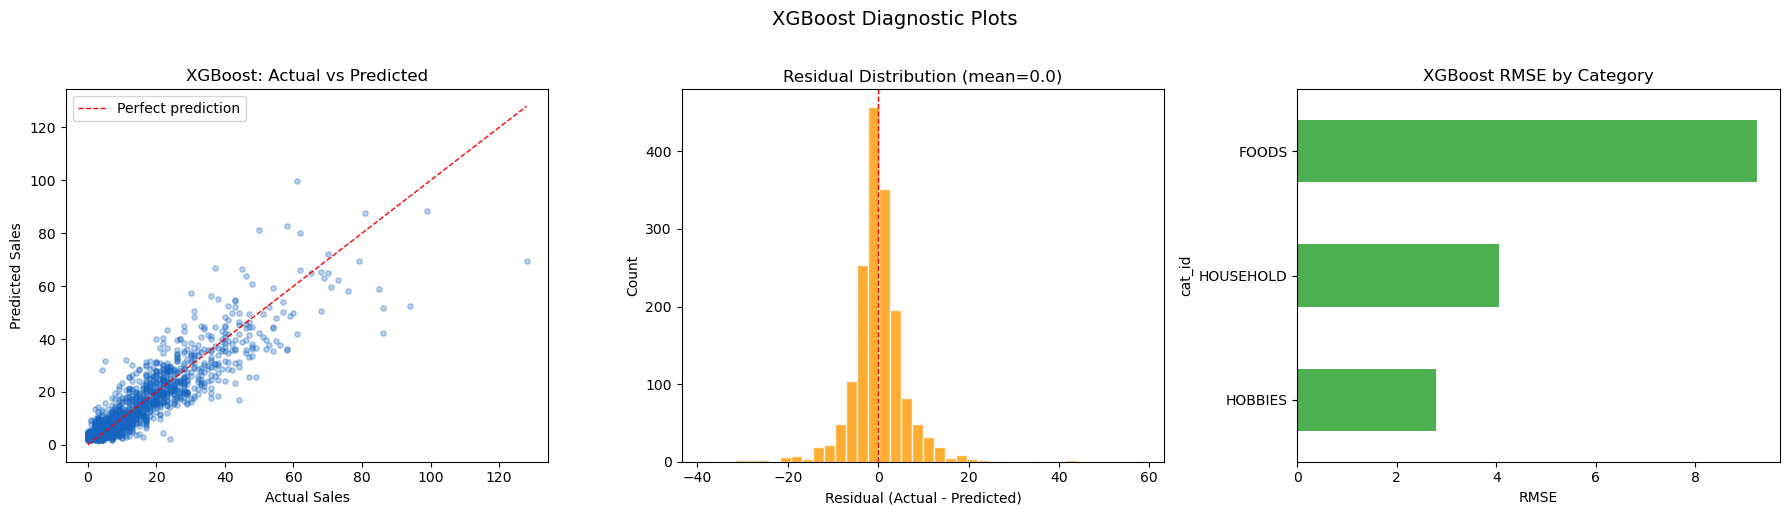

Saved: figures/xgb_diagnostics.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
ax = axes[0]
ax.scatter(holdout['sales'], holdout['pred_xgb'], alpha=0.3, s=15, color='#1565C0')
max_val = max(holdout['sales'].max(), holdout['pred_xgb'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title('XGBoost: Actual vs Predicted')
ax.legend()

# 2. Residual distribution
ax = axes[1]
residuals = holdout['sales'] - holdout['pred_xgb']
ax.hist(residuals, bins=40, color='#FF9800', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (mean={residuals.mean():.1f})')

# 3. RMSE by category
ax = axes[2]
cat_rmse = holdout.groupby('cat_id').apply(
    lambda g: np.sqrt(mean_squared_error(g['sales'], g['pred_xgb']))
).sort_values()
cat_rmse.plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_xlabel('RMSE')
ax.set_title('XGBoost RMSE by Category')

plt.suptitle('XGBoost Diagnostic Plots', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/xgb_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/xgb_diagnostics.png')

### Residuals Over Time by Category

The residual distribution (above) shows the overall shape, but hides *when* errors occur. If residuals spike on specific dates — holidays, SNAP issuance days, promotional periods — it reveals where the model's assumptions break down and where category-specific adjustments may be needed.

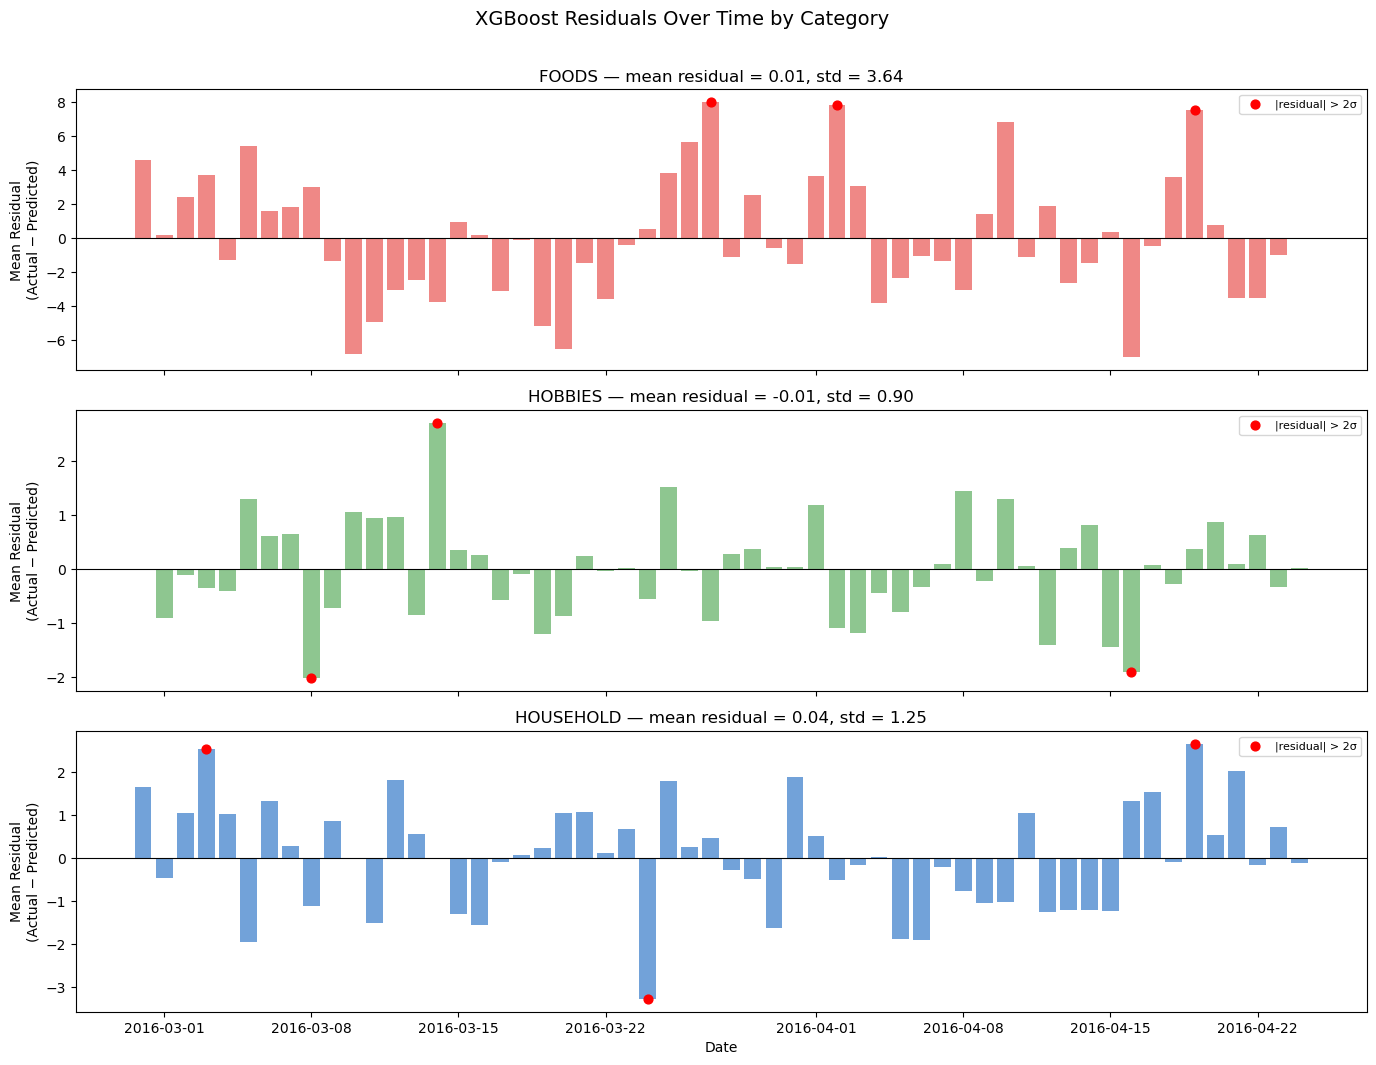

Saved: figures/xgb_residuals_over_time.png


In [15]:
holdout['residual_xgb'] = holdout['sales'] - holdout['pred_xgb']

cats = sorted(holdout['cat_id'].unique())
cat_colors = {'FOODS': '#E53935', 'HOUSEHOLD': '#1565C0', 'HOBBIES': '#43A047'}

fig, axes = plt.subplots(len(cats), 1, figsize=(14, 3.5 * len(cats)), sharex=True)

for i, cat in enumerate(cats):
    ax = axes[i]
    cat_data = holdout[holdout['cat_id'] == cat].groupby('date')['residual_xgb'].mean().sort_index()
    color = cat_colors.get(cat, '#555')

    ax.bar(cat_data.index, cat_data.values, color=color, alpha=0.6, width=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')

    # Highlight large residual days (|mean residual| > 2 std)
    threshold = cat_data.std() * 2
    spikes = cat_data[cat_data.abs() > threshold]
    if len(spikes) > 0:
        ax.scatter(spikes.index, spikes.values, color='red', s=40, zorder=5, label=f'|residual| > 2\u03c3')
        ax.legend(fontsize=8)

    ax.set_ylabel('Mean Residual\n(Actual \u2212 Predicted)')
    ax.set_title(f'{cat} — mean residual = {cat_data.mean():.2f}, std = {cat_data.std():.2f}')

axes[-1].set_xlabel('Date')
plt.suptitle('XGBoost Residuals Over Time by Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/xgb_residuals_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/xgb_residuals_over_time.png')

### Model Comparison — RMSE by Model

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall RMSE
ax = axes[0]
comp_sorted = comparison.sort_values('RMSE')
bars = ax.barh(comp_sorted['Model'], comp_sorted['RMSE'], color=['#4CAF50', '#1565C0', '#FF9800'])
ax.set_xlabel('RMSE (lower is better)')
ax.set_title('Overall RMSE')
for bar, val in zip(bars, comp_sorted['RMSE']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=10)

# RMSE by category
ax = axes[1]
cats = sorted(holdout['cat_id'].unique())
x = np.arange(len(cats))
w = 0.2
for i, (col, color, label) in enumerate(zip(
    ['pred_naive', 'pred_ridge', 'pred_xgb'],
    ['#FF9800', '#1565C0', '#4CAF50'],
    ['Naive', 'Ridge', 'XGBoost']
)):
    rmses = [np.sqrt(mean_squared_error(holdout.loc[holdout['cat_id']==c, 'sales'],
                                         holdout.loc[holdout['cat_id']==c, col])) for c in cats]
    ax.bar(x + i*w, rmses, w, label=label, color=color, alpha=0.8)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(cats)
ax.set_ylabel('RMSE')
ax.set_title('RMSE by Category')
ax.legend()

plt.suptitle('Model Comparison', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/model_comparison.png')

### Interpretation

**XGBoost is the best model by RMSE** across all three categories, achieving the lowest holdout error. Ridge comes second, and Seasonal Naive sets the floor.

However, all three models were trained to minimize **squared error** — a symmetric loss function that targets the **conditional mean** $E[Y|X]$. This is optimal only when overstocking and understocking carry equal cost.

In practice:
- **FOODS**: understocking perishable, high-frequency groceries loses repeat customers ($C_u >> C_o$)
- **HOUSEHOLD**: understocking durable goods loses a sale, but excess inventory has low holding cost ($C_u > C_o$)
- **HOBBIES**: low-demand discretionary items — costs are roughly symmetric ($C_u \approx C_o$)

The question for notebook 04: **can we do better by training models that directly account for these asymmetric costs**, rather than optimizing RMSE and adjusting after the fact?

---

## Step 8: Forecast vs. Actual — Holdout Time Series by Category

We select one representative group per category and overlay all three models' predictions against actual sales over the 56-day holdout window. This reveals whether models track demand dynamics (trend, spikes, weekly patterns) or merely approximate the level.

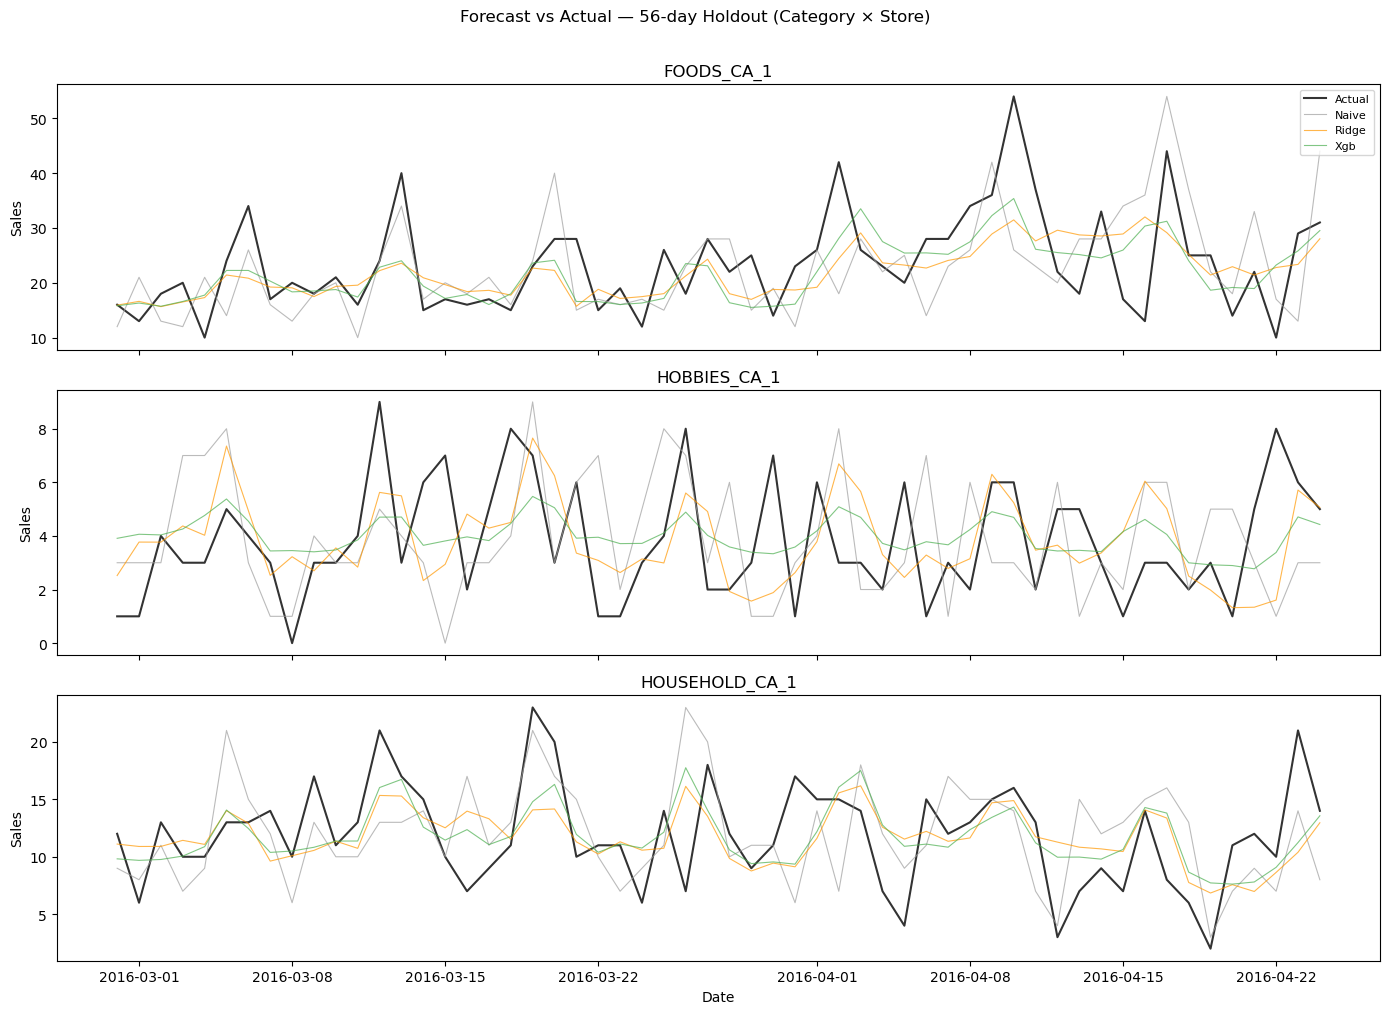

Saved: figures/forecast_vs_actual.png


In [17]:
sample_groups = holdout.groupby('cat_id')['id'].first().values[:3]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = {'pred_naive': '#9E9E9E', 'pred_ridge': '#FF9800', 'pred_xgb': '#4CAF50'}

for i, sample_id in enumerate(sample_groups):
    s = holdout[holdout['id'] == sample_id].sort_values('date')
    ax = axes[i]
    ax.plot(s['date'], s['sales'], 'k-', linewidth=1.5, label='Actual', alpha=0.8)
    for col, color in colors.items():
        label = col.replace('pred_', '').title()
        ax.plot(s['date'], s[col], color=color, linewidth=0.8, alpha=0.7, label=label)
    ax.set_ylabel('Sales')
    ax.set_title(str(sample_id))
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[2].set_xlabel('Date')
plt.suptitle('Forecast vs Actual \u2014 56-day Holdout (Category \u00d7 Store)', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/forecast_vs_actual.png')

---

## Step 9: Save Predictions for Notebook 04

Save holdout predictions for all three models. Notebook 04 (Regret Strategies) will:
1. Evaluate these RMSE-optimized predictions under **asymmetric inventory costs**
2. Show that post-hoc quantile adjustments can partially bridge the gap
3. Train **regret-aware models** (quantile regression) that directly target the cost-optimal quantile — and compare them against these RMSE baselines

In [18]:
pred_cols = ['pred_naive', 'pred_ridge', 'pred_xgb']
output = holdout[['id', 'cat_id', 'store_id', 'state_id', 'date', 'sales'] + pred_cols].copy()
output.to_csv(f'{OUTPUT_DIR}/predictions.csv', index=False)
print(f'Saved: predictions.csv ({len(output):,} rows x {output.shape[1]} cols)')
print(f'Columns: {list(output.columns)}')

for col in pred_cols:
    assert (output[col] >= 0).all(), f'{col} has negative predictions!'
    print(f'  {col}: min={output[col].min():.1f}, mean={output[col].mean():.1f}, max={output[col].max():.1f}')

print(f'\n=== Notebook 03 complete. Next: 04_regret_strategies ===')

Saved: predictions.csv (1,680 rows x 9 cols)
Columns: ['id', 'cat_id', 'store_id', 'state_id', 'date', 'sales', 'pred_naive', 'pred_ridge', 'pred_xgb']
  pred_naive: min=0.0, mean=13.8, max=128.0
  pred_ridge: min=0.0, mean=13.7, max=79.5
  pred_xgb: min=1.6, mean=13.9, max=99.6

=== Notebook 03 complete. Next: 04_regret_strategies ===


---

## Conclusion

Three models were evaluated on the 56-day holdout at the **category × store** level (30 groups). All were trained on the same 26-feature dataset from NB02; XGBoost used early stopping on a 56-day inner-train validation slice (with `best_iteration` then refit on full train) so the holdout was touched only once for final evaluation.

### Headline holdout results

| Model | RMSE | MAE | Notes |
|---|---|---|---|
| Seasonal Naive | 8.41 | 5.37 | Predicts $\hat{y}_t = y_{t-7}$. Strong baseline, no parameters. |
| Ridge | 6.38 | 4.11 | Linear, fast, interpretable. ~24% better than Naive. |
| **XGBoost** | **6.05** | **3.90** | Best on RMSE. Adds ~5% on top of Ridge by capturing nonlinear interactions (PDP confirms threshold effect on `snap_issuance_proximity`). |

### What this tells us

- The largest gain (Naive → Ridge) comes from **using features at all**. The smaller Ridge → XGBoost gap suggests most of the demand signal at the aggregated level is approximately linear — but XGBoost still captures conditional interactions Ridge misses, particularly around SNAP and event proximity thresholds.
- The Ridge `sell_price` coefficient is positive (~+2.3), but SHAP analysis on XGBoost shows price has near-zero effect on predictions. This indicates the Ridge coefficient is a **level-effect confound** (high-priced category-stores happen to be high-volume), not a price elasticity. Treat it as a methodological caution, not a finding.

### Caveat — and what NB04 does about it

RMSE assumes overpredicting by 100 units is equally costly as underpredicting by 100 units. In real Walmart inventory decisions, understocking (lost sales, lost trips, customer attrition) is typically more expensive than overstocking (carrying cost, eventual markdown). NB04 introduces asymmetric inventory costs (the newsvendor framework) and quantile regression to test whether the RMSE-best model is also the cost-best model.

**Output**: `predictions.csv` with all three models' holdout predictions, consumed by NB04.